In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

In [8]:
load_dataset('dair-ai/emotion')

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [9]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']

test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

print(emotion_dataset['train'])
print("\n")

print(f"{emotion_dataset['train'].features['label'].names}\n")
print("\n")
#print(label_names)
print(train_text)

print("\n")

print(train_label)

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})


['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']



Column(['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'im grabbing a minute to post i feel greedy wrong', 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property', 'i am feeling grouchy'])


Column([0, 0, 3, 2, 3])


In [10]:
emotion_dataset.keys()
emotion_dataset['train'].to_pandas().head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [11]:
label_names = emotion_dataset['train'].features['label'].names
#label_names

for i in train_label:
  print(f"{i} {label_names[i]}")

Streaming output truncated to the last 5000 lines.
0 sadness
0 sadness
3 anger
4 fear
2 love
1 joy
3 anger
0 sadness
0 sadness
1 joy
4 fear
1 joy
4 fear
2 love
2 love
3 anger
3 anger
0 sadness
4 fear
0 sadness
0 sadness
5 surprise
2 love
1 joy
1 joy
2 love
0 sadness
1 joy
1 joy
4 fear
0 sadness
3 anger
3 anger
0 sadness
2 love
4 fear
4 fear
3 anger
3 anger
1 joy
0 sadness
0 sadness
1 joy
1 joy
4 fear
0 sadness
1 joy
2 love
4 fear
3 anger
0 sadness
1 joy
3 anger
5 surprise
4 fear
1 joy
1 joy
2 love
4 fear
0 sadness
1 joy
3 anger
4 fear
3 anger
0 sadness
0 sadness
0 sadness
3 anger
0 sadness
4 fear
1 joy
3 anger
3 anger
0 sadness
4 fear
1 joy
3 anger
4 fear
0 sadness
1 joy
4 fear
1 joy
2 love
3 anger
4 fear
4 fear
4 fear
4 fear
1 joy
3 anger
3 anger
0 sadness
1 joy
0 sadness
1 joy
0 sadness
0 sadness
1 joy
0 sadness
4 fear
4 fear
1 joy
0 sadness
1 joy
0 sadness
1 joy
4 fear
3 anger
0 sadness
1 joy
3 anger
1 joy
1 joy
0 sadness
1 joy
1 joy
3 anger
3 anger
1 joy
1 joy
1 joy
0 sadness
1 joy

In [12]:
df_train = pd.DataFrame(
    {
        'text': train_text,
        'label': [label_names[i] for i in train_label]
    }
)
df_test = pd.DataFrame(
    {
        'text': test_text,
        'label': [label_names[i] for i in test_label]
    }
)
#df_test.head()
df_train.isnull().sum()

,0
text,0
label,0


**EDA**


*   Done to check the overall situation of the dataset (e.g class distribution, biasness...)



In [13]:
count = df_train['label'].value_counts().index

<Axes: xlabel='label', ylabel='count'>

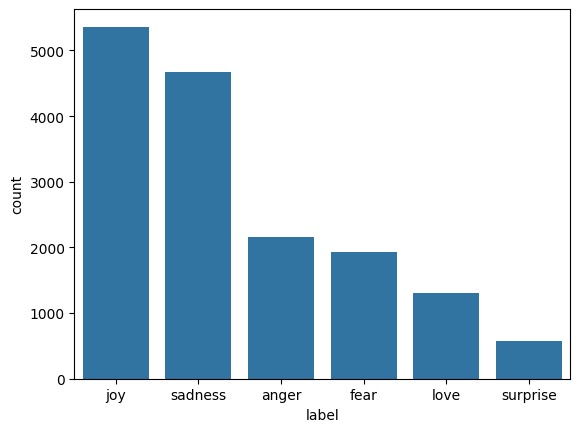

In [14]:
sns.countplot(x= 'label', data = df_train, order = count)

Data Preprocessing

Tokenize

Tokenizer

padded sequence

In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000

tokenizer = Tokenizer(num_words = max_words, oov_token = '<unk')

tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
#train_sequence

test_sequence = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence, maxlen = 50, padding= 'post', truncating = 'post')

padded_test_sequence = pad_sequences(test_sequence, maxlen = 50, padding= 'post', truncating = 'post')

print(padded_train_sequence)

train_labels = np.array(train_label)
test_labels = np.array(test_label)

num_classes = len(np.unique(train_labels))
#num_classes

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")



[[   2  139    3 ...    0    0    0]
 [   2   40  101 ...    0    0    0]
 [  17 3060    7 ...    0    0    0]
 ...
 [   2    3  327 ...    0    0    0]
 [   2    3   14 ...    0    0    0]
 [   2   47    7 ...    0    0    0]]
Vocabulary size: 15213
Max Sentence Length: 50


class balancing via weights

enumerate

In [16]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(train_labels),
    y = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [17]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True
)

Model-1: Simple RNN

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU


model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
    SimpleRNN(units = 128, return_sequences = True),
    Dropout(0.5),
    SimpleRNN(units = 64),
    Dropout(0.5),
    Dense(num_classes, activation = 'softmax')
])

rnn_model = model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence, test_labels),
    epochs = 20,
    batch_size = 32,
    #validation_split = 0.2,
    class_weight = class_weight_dict,
    callbacks = [early_stopping]
)
rnn_loss, rnn_accuracy = model.evaluate(padded_test_sequence, test_labels)
print(f"Simple RNN Test Loss: {model.evaluate(padded_test_sequence, test_labels)}")
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 43ms/step - accuracy: 0.1562 - loss: 2.0329 - val_accuracy: 0.1420 - val_loss: 1.7860
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.1443 - loss: 1.8875 - val_accuracy: 0.1065 - val_loss: 1.7804
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.1279 - loss: 1.8269 - val_accuracy: 0.1090 - val_loss: 1.8058
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.1351 - loss: 1.8056 - val_accuracy: 0.2055 - val_loss: 1.7681
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.1291 - loss: 1.8028 - val_accuracy: 0.0460 - val_loss: 1.8156
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1420 - loss: 1.7860
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1420 - loss: 1.7860
Simple RNN Test Loss: [1.7859901189804077, 0.1420000046491623]
RNN Loss: 1.7859901189804077
RNN Accuracy: 0.1420000046491623


LSTM

In [ ]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
    LSTM(units = 128, return_sequences = True),
    Dropout(0.5),
    LSTM(units = 64),
    Dropout(0.5),
    Dense(num_classes, activation = 'softmax')
])

lstm_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence, test_labels),
    epochs = 20,
    batch_size = 32,
    class_weight = class_weight_dict,
    callbacks = [early_stopping]
)
lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"Simple LSTM Test Loss: {lstm_model.evaluate(padded_test_sequence, test_labels)}")
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 62s 118ms/step - accuracy: 0.1503 - loss: 1.7952 - val_accuracy: 0.1350 - val_loss: 1.8219
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 115ms/step - accuracy: 0.1610 - loss: 1.7937 - val_accuracy: 0.1385 - val_loss: 1.7902
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 114ms/step - accuracy: 0.1440 - loss: 1.7925 - val_accuracy: 0.0800 - val_loss: 1.7962
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 114ms/step - accuracy: 0.1402 - loss: 1.7925 - val_accuracy: 0.1375 - val_loss: 1.7960
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 113ms/step - accuracy: 0.1775 - loss: 1.7784 - val_accuracy: 0.1005 - val_loss: 1.8025
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.1350 - loss: 1.8219
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.1350 - loss: 1.8219
Simple LSTM Test Loss: [1.8218634128570557, 0.13500000536441803]
LSTM Loss: 1.8218634128570557
LSTM Accuracy: 0.13500000536441803


GRU

In [19]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
    GRU(units = 128, return_sequences = True),
    Dropout(0.5),
    GRU(units = 64),
    Dropout(0.5),
    Dense(num_classes, activation = 'softmax')
])

gru_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence, test_labels),
    epochs = 20,
    batch_size = 32,
    class_weight = class_weight_dict,
    callbacks = [early_stopping]
)
gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"Simple gru Test Loss: {gru_model.evaluate(padded_test_sequence, test_labels)}")
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 61s 116ms/step - accuracy: 0.1599 - loss: 1.7967 - val_accuracy: 0.0815 - val_loss: 1.7873
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 114ms/step - accuracy: 0.1587 - loss: 1.7951 - val_accuracy: 0.1125 - val_loss: 1.8038
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 113ms/step - accuracy: 0.1576 - loss: 1.7943 - val_accuracy: 0.0330 - val_loss: 1.8309
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 111ms/step - accuracy: 0.1510 - loss: 1.7936 - val_accuracy: 0.1440 - val_loss: 1.7753
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 111ms/step - accuracy: 0.1710 - loss: 1.7906 - val_accuracy: 0.0860 - val_loss: 1.8190
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 112ms/step - accuracy: 0.1797 - loss: 1.7725 - val_accuracy: 0.3150 - val_loss: 1.7842
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 113ms/step - accuracy: 0.2056 - loss: 1.7394 - val_accuracy: 0.1290 - val_loss: 1.8384
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 112ms/step - accuracy: 0.2300 - loss: 1

ranking and selection

In [ ]:
result_df = pd.DataFrame({
    "Model": ['RNN', 'LSTM', "GRU"],
    "Test Loss": [rnn_loss, lstm_loss, gru_loss],
    "Test Accuracy": [rnn_accuracy, lstm_accuracy, gru_accuracy]
}).sort_values(by = 'Test Accuracy', ascending = False)

result_df


,Model,Test Loss,Test Accuracy
0,RNN,1.785990,0.1420
1,LSTM,1.821863,0.1350
2,GRU,1.808756,0.0795


Bidirectional GRU

left to right,

right to left

In [20]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300, input_length = 50),
    Bidirectional(GRU(units = 128, return_sequences = True)),
    Dropout(0.5),
    Bidirectional(GRU(units = 64)),
    Dropout(0.5),
    Dense(num_classes, activation = 'softmax')
])

BiGRU.compile(optimizer = 'adam', loss = "sparse_categorical_crossentropy", metrics = ['accuracy'])

BiGRU.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence, test_labels),
    epochs = 20,
    batch_size = 32,
    class_weight = class_weight_dict,
    callbacks = [early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 167s 323ms/step - accuracy: 0.5871 - loss: 0.9950 - val_accuracy: 0.8950 - val_loss: 0.2942
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 158s 316ms/step - accuracy: 0.9229 - loss: 0.2244 - val_accuracy: 0.9200 - val_loss: 0.2161
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 201s 314ms/step - accuracy: 0.9433 - loss: 0.1594 - val_accuracy: 0.9295 - val_loss: 0.1824
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 200s 310ms/step - accuracy: 0.9589 - loss: 0.1077 - val_accuracy: 0.9210 - val_loss: 0.2620
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 156s 312ms/step - accuracy: 0.9651 - loss: 0.1001 - val_accuracy: 0.9250 - val_loss: 0.2499
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 203s 315ms/step - accuracy: 0.9751 - loss: 0.0717 - val_accuracy: 0.9105 - val_loss: 0.2830
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 157s 314ms/step - accuracy: 0.9787 - loss: 0.0589 - val_accuracy: 0.9120 - val_loss: 0.3268
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 158s 316ms/step - accuracy: 0.9808 -

Evaluation

In [22]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.9295 - loss: 0.1824
BiGRU Loss: 0.18239741027355194
BiGRU Accuracy: 0.9294999837875366


63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step


<Axes: >

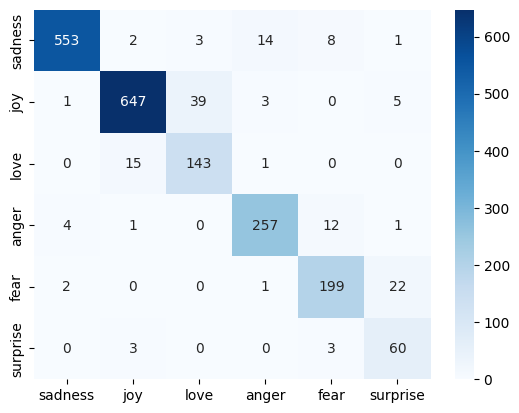

In [23]:
from sklearn.metrics import classification_report, confusion_matrix


BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence), axis = 1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions), annot = True, fmt = 'd', cmap = 'Blues', xticklabels = label_names, yticklabels = label_names)

testing

In [25]:
sample_texts_1 = [
    'I am absolutely over the moon about my promotion',
    'i have been with petronas for years i feel that petronas has performed well and made a huge profit',
    'i feel romantic too',
    'Yay! We finally graduated!',
    'i now feel compromised and skeptical of the value of every unit of work i put in',
    'My heart pounded wildly against my ribs as the shadow moved closer',
    'i feel selfish and spoiled',
    'Wow! I never expected to see you here today!',
    'What? You mean we won the grand prize?'
]

sample_texts_2 = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts_2)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen = 100, padding = 'post', truncating = 'post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis = 1)
#sample_predictions

for i in range(len(sample_texts_2)):
  print(f"Text: {sample_texts_2[i]}\nPredicted Label: {label_names[sample_predictions[i]]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Label: joy
Text: I feel so alone and hopeless today.
Predicted Label: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Label: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Label: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Label: surprise


Save Model

In [27]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok = True)

#BiGRU.save(os.path.join(model_dir, 'BiGRU_model.h5'))
BiGRU.save(os.path.join(model_dir, 'BiGRU_model.keras'))

with open(os.path.join(model_dir, 'tokenizer.pkl'),'wb') as file:
  pickle.dump(tokenizer, file)

In [28]:
BiGRU.save_weights(os.path.join(model_dir, 'BiGRU_model.weights.h5'))

In [ ]:
BiGRU.save_weights(os.path.join(model_dir, 'BiGRU_model.weights.h5'))

In [26]:
import tensorflow as tf

print(tf.__version__)
print(tf.keras.__version__)

2.20.0
3.13.2
